In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# import requires lib


In [2]:
#load the dataset
df = pd.read_csv("customer_churn.csv")

In [5]:
df
df.head(7)

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,gender,region,churn
0,56,NaN,770.887470,29,84.828689,143,90,1,Male,South,1
1,69,53051.954538,622.025467,41,133.943805,72,96,4,Female,East,1
2,46,38654.738821,665.727931,36,114.993023,155,88,3,Male,North,1
3,32,28666.194356,715.281358,29,153.875284,76,110,2,Male,South,0
4,60,40301.406736,NaN,27,115.391031,168,99,2,Male,East,1
5,25,NaN,526.743383,18,104.602284,286,37,4,Female,South,0
6,38,75307.124526,NaN,40,141.636341,84,96,1,Female,North,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1000 non-null   int64  
 1   income                 951 non-null    float64
 2   credit_score           950 non-null    float64
 3   transactions_month     1000 non-null   int64  
 4   avg_purchase_value     950 non-null    float64
 5   days_since_last_login  1000 non-null   int64  
 6   tenure_months          1000 non-null   int64  
 7   num_products           1000 non-null   int64  
 8   gender                 1000 non-null   object 
 9   region                 1000 non-null   object 
 10  churn                  1000 non-null   int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 86.1+ KB


In [7]:
df.describe()

,age,income,credit_score,transactions_month,avg_purchase_value,days_since_last_login,tenure_months,num_products,churn
count,1000.00000,951.000000,950.000000,1000.000000,950.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,43.81900,55354.417513,651.422837,29.842000,119.301574,182.155000,60.394000,3.129000,0.517000
std,14.99103,32708.500386,68.271995,5.453511,39.619144,104.205824,34.163166,1.410088,0.499961
min,18.00000,7271.860691,444.172796,15.000000,-7.068153,0.000000,1.000000,1.000000,0.000000
25%,31.00000,40959.853770,605.096009,26.000000,93.330104,88.000000,31.000000,2.000000,0.000000
50%,44.00000,51298.846812,650.746768,30.000000,119.585761,184.000000,61.000000,3.000000,1.000000
75%,56.00000,61285.465584,697.845647,33.000000,146.374081,273.250000,89.250000,4.000000,1.000000
max,69.00000,254852.478291,873.517530,49.000000,244.516408,364.000000,119.000000,5.000000,1.000000


<Axes: ylabel='transactions_month'>

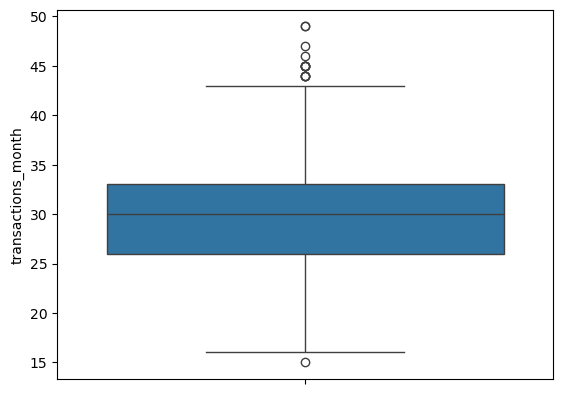

In [11]:
# make the box plot
sns.boxplot(df['transactions_month'])

In [25]:
# step 4 Data 

# handle the missing value using median of all num columns
#1. income
income_median=df['income'].median()
income_median = round(income_median,2)
income_median
#credit score
credit_median=df['credit_score'].median()
credit_median=round(credit_median,2)
credit_median
#avg_purphase
purchase_value_med = round(df['avg_purchase_value'].median(),2)

#handle missing value

#credit_score
df['credit_score'].fillna(credit_median, inplace=True)

#income
df['income'].fillna(income_median, inplace = True)
#average_pur
df['avg_purchase_value'].fillna(purchase_value_med,inplace=True)

C:\Users\ntt\AppData\Local\Temp\ipykernel_2036\952371112.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['credit_score'].fillna(credit_median, inplace=True)
C:\Users\ntt\AppData\Local\Temp\ipykernel_2036\952371112.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [33]:
#step5 handled outlier
outlier_cols  = ['income','credit_score','avg_purchase_value']

for col in outlier_cols:

    # find the Q1 and Q3
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)

    # find the IQR
    IQR = Q3 - Q1

    # Find the upper bound and lower bound 
    lower_bound =  Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    # handled the outlier
    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)


In [27]:
# handled cat columns
df['gender'].replace({'Male':1,'Female':0},inplace=True)


C:\Users\ntt\AppData\Local\Temp\ipykernel_2036\1099039322.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'].replace({'Male':1,'Female':0},inplace=True)


In [36]:
#st Divide into x and y

x = df.drop('churn',axis=1)
y=df['churn']




In [41]:
# next part 

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state= 42)



In [42]:
# step 7 Model buidling
from sklearn.linear_model import LogisticRegression

# credit the instance of model
LR = LogisticRegression()

# train the model
model = LR.fit(x_train,y_train)

# prediction on testing
y_pred = model.predict(x_test)

c:\Users\ntt\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
# step 8: Model evaluating metrices
from sklearn.metrics import accuracy_score

# find accuracy
ac = accuracy_score(y_test,y_pred)
print('Accuracy of model', ac)

Accuracy of model 0.53
